In [ ]:
import warnings

warnings.filterwarnings(
    "ignore")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

uploaded = files.upload()
xlsx_path = list(uploaded.keys())[0]

Saving Dataviz_proj_all_datasets.xlsx to Dataviz_proj_all_datasets.xlsx


In [ ]:
raw_sheets = pd.read_excel(xlsx_path, sheet_name=None)
print("Sheets found:", list(raw_sheets.keys()))

signatures = {
    "closed_deals": {"mql_id","seller_id","sdr_id","sr_id","won_date","business_segment",
                      "lead_type","lead_behaviour_profile","has_company","has_gtin",
                      "average_stock","business_type","declared_product_catalog_size",
                      "declared_monthly_revenue"},
    "mql":          {"mql_id","first_contact_date","landing_page_id","origin"},
    "customers":    {"customer_id","customer_unique_id","customer_zip_code_prefix",
                      "customer_city","customer_state"},
    "geolocation":  {"geolocation_zip_code_prefix","geolocation_lat","geolocation_lng",
                      "geolocation_city","geolocation_state"},
    "order_items":  {"order_id","order_item_id","product_id","seller_id",
                      "shipping_limit_date","price","freight_value"},
    "payments":     {"order_id","payment_sequential","payment_type",
                      "payment_installments","payment_value"},
    "reviews":      {"review_id","order_id","review_score","review_comment_title",
                      "review_comment_message","review_creation_date","review_answer_timestamp"},
    "orders":       {"order_id","customer_id","order_status","order_purchase_timestamp",
                      "order_approved_at","order_delivered_carrier_date",
                      "order_delivered_customer_date","order_estimated_delivery_date"},
    "category_translation": {"product_category_name","product_category_name_english"},
    "products":     {"product_id","product_category_name","product_name_lenght",
                      "product_description_lenght","product_photos_qty","product_weight_g",
                      "product_length_cm","product_height_cm","product_width_cm"},
    "sellers":      {"seller_id","seller_zip_code_prefix","seller_city","seller_state"},
}

def best_match(cols, signatures):
    cols = set(cols)
    scores = {}
    for name, sig in signatures.items():
        overlap = len(cols & sig)
        scores[name] = overlap / len(sig)
    best = max(scores, key=scores.get)
    return best, scores[best]

data = {}
used_sheets = {}
for sheet_name, df in raw_sheets.items():
    name, score = best_match(df.columns, signatures)
    if score >= 0.7:
        data[name] = df.copy()
        used_sheets[name] = sheet_name
    else:
        print(f"could not match sheet '{sheet_name}' (best guess: {name}, score={score:.2f})")

print("\nAuto-mapped datasets:")
for k, v in used_sheets.items():
    print(f"  {k:22s} <- sheet '{v}'")

missing = set(signatures.keys()) - set(data.keys())
if missing:
    print("Missing/unmatched datasets:", missing)

Sheets found: ['closed_deals', 'customers_dataset', 'geolocation_dataset', 'marketing_qualified_leads_datas', 'order_items_dataset', 'order_payments_dataset', 'order_reviews_dataset', 'orders_dataset', 'product_category_name_translati', 'products_dataset', 'sellers_dataset']

Auto-mapped datasets:
  closed_deals           <- sheet 'closed_deals'
  customers              <- sheet 'customers_dataset'
  geolocation            <- sheet 'geolocation_dataset'
  mql                    <- sheet 'marketing_qualified_leads_datas'
  order_items            <- sheet 'order_items_dataset'
  payments               <- sheet 'order_payments_dataset'
  reviews                <- sheet 'order_reviews_dataset'
  orders                 <- sheet 'orders_dataset'
  category_translation   <- sheet 'product_category_name_translati'
  products               <- sheet 'products_dataset'
  sellers                <- sheet 'sellers_dataset'


In [ ]:
# Parse all date-like columns automatically
date_cols_map = {
    "orders": ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
               "order_delivered_customer_date","order_estimated_delivery_date"],
    "reviews": ["review_creation_date","review_answer_timestamp"],
    "order_items": ["shipping_limit_date"],
    "mql": ["first_contact_date"],
    "closed_deals": ["won_date"],
}

for key, cols in date_cols_map.items():
    if key in data:
        for c in cols:
            if c in data[key].columns:
                data[key][c] = pd.to_datetime(data[key][c], errors="coerce")

# sanity check
for k, df in data.items():
    print(k, df.shape)

closed_deals (842, 14)
customers (99441, 5)
geolocation (1000163, 5)
mql (8000, 4)
order_items (112650, 7)
payments (103886, 5)
reviews (99224, 7)
orders (99441, 8)
category_translation (71, 2)
products (32951, 9)
sellers (3095, 4)


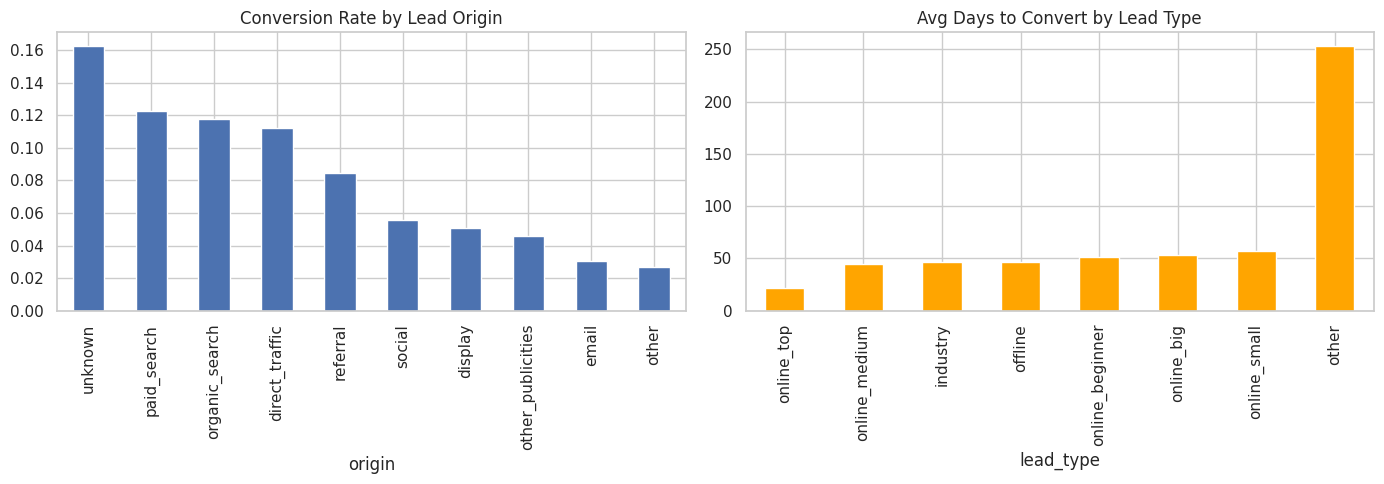

In [ ]:
#Q1: Lead conversion by origin/lead type
mql = data["mql"]
closed = data["closed_deals"]

funnel = mql.merge(closed, on="mql_id", how="left")
funnel["converted"] = funnel["won_date"].notna()
funnel["days_to_convert"] = (funnel["won_date"] - funnel["first_contact_date"]).dt.days

conv_by_origin = funnel.groupby("origin")["converted"].mean().sort_values(ascending=False)
avg_days_by_type = funnel.groupby("lead_type")["days_to_convert"].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14,5))
conv_by_origin.plot(kind="bar", ax=ax[0], title="Conversion Rate by Lead Origin")
avg_days_by_type.plot(kind="bar", ax=ax[1], color="orange", title="Avg Days to Convert by Lead Type")
plt.tight_layout(); plt.show()

                            revenue  avg_review
lead_behaviour_profile                         
shark                   4951.242000    4.231680
eagle                   1814.496600    4.252294
cat                     1537.534565    4.244438
eagle, cat               896.000000    3.750000
wolf                     500.392791    4.341974
cat, wolf                 59.000000    5.000000


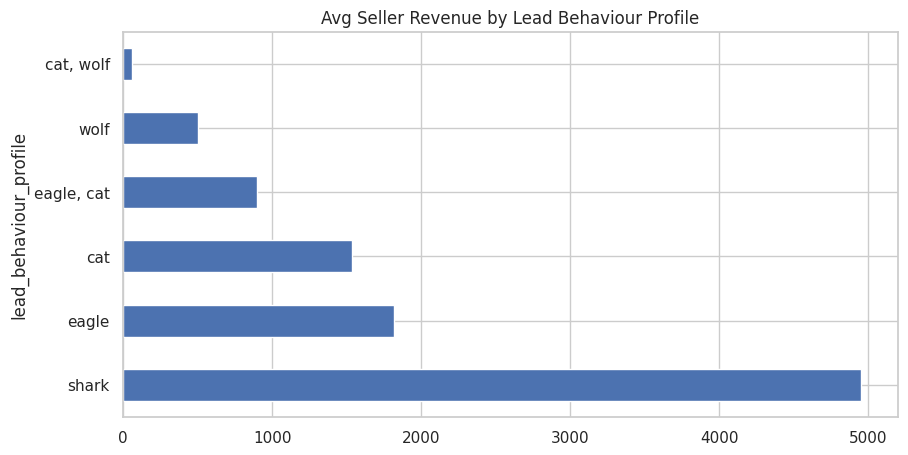

In [ ]:
#Q2: Do lead-source sellers perform differently once live?
sellers = data["sellers"]
order_items = data["order_items"]
orders = data["orders"]
reviews = data["reviews"]


seller_perf = (order_items.merge(orders, on="order_id")
                          .merge(reviews, on="order_id", how="left")
                          .groupby("seller_id")
                          .agg(revenue=("price","sum"),
                               avg_review=("review_score","mean"),
                               n_orders=("order_id","nunique"))
                          .reset_index())

lead_perf = closed.merge(seller_perf, on="seller_id", how="inner")

perf_by_behavior = lead_perf.groupby("lead_behaviour_profile")[["revenue","avg_review"]].mean().sort_values("revenue", ascending=False)
print(perf_by_behavior)

perf_by_behavior["revenue"].plot(kind="barh", title="Avg Seller Revenue by Lead Behaviour Profile")
plt.show()

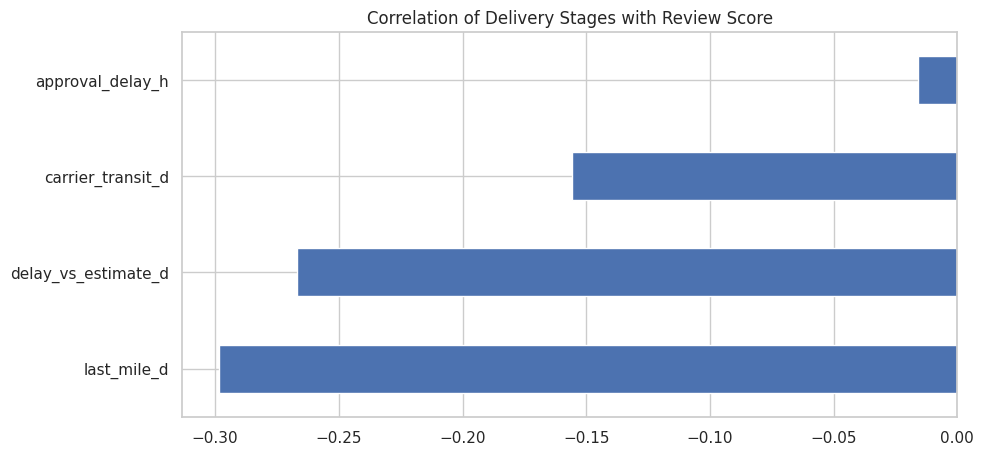

In [ ]:
#Q3: Where does the delivery timeline break down?
o = orders.dropna(subset=["order_approved_at","order_delivered_carrier_date","order_delivered_customer_date"]).copy()

o["approval_delay_h"]   = (o["order_approved_at"] - o["order_purchase_timestamp"]).dt.total_seconds()/3600
o["carrier_transit_d"]  = (o["order_delivered_carrier_date"] - o["order_approved_at"]).dt.days
o["last_mile_d"]        = (o["order_delivered_customer_date"] - o["order_delivered_carrier_date"]).dt.days
o["delay_vs_estimate_d"]= (o["order_delivered_customer_date"] - o["order_estimated_delivery_date"]).dt.days

o_rev = o.merge(reviews[["order_id","review_score"]], on="order_id", how="left")

stage_corr = o_rev[["approval_delay_h","carrier_transit_d","last_mile_d",
                     "delay_vs_estimate_d","review_score"]].corr()["review_score"].drop("review_score")
stage_corr.sort_values().plot(kind="barh", title="Correlation of Delivery Stages with Review Score")
plt.show()

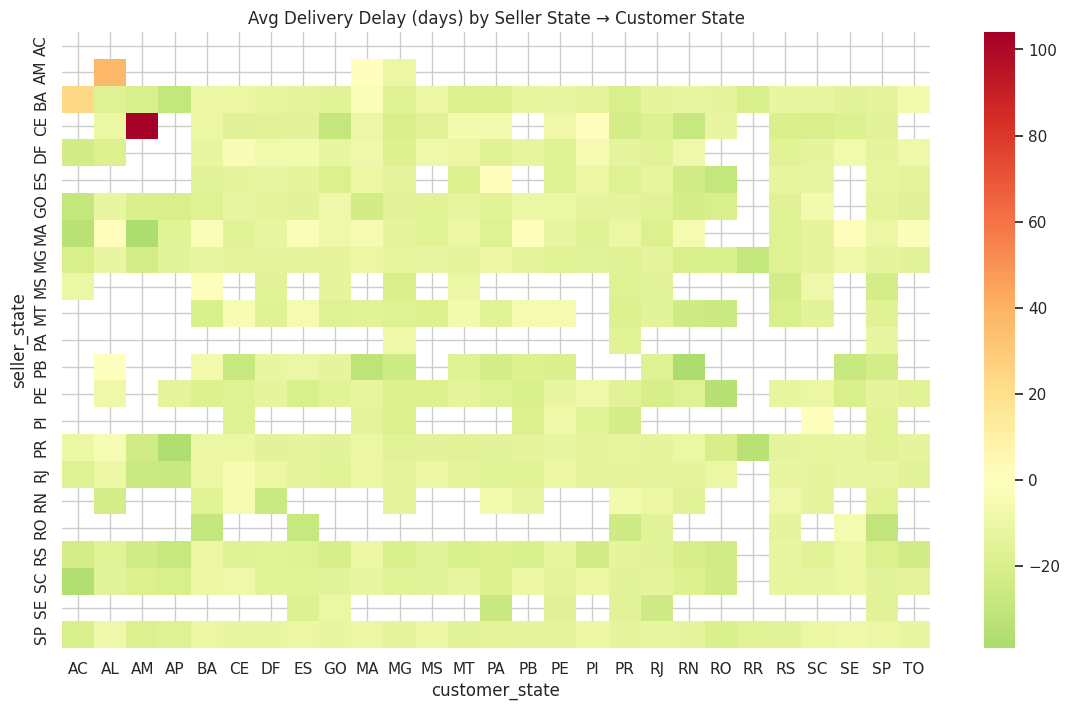

In [ ]:
#Q4: Geographic logistics penalty (seller state → customer state)
route = (order_items.merge(sellers, on="seller_id")
                    .merge(orders, on="order_id")
                    .merge(data["customers"], on="customer_id"))

route["delay_d"] = (route["order_delivered_customer_date"] - route["order_estimated_delivery_date"]).dt.days
route_delay = (route.groupby(["seller_state","customer_state"])["delay_d"]
                    .mean().reset_index()
                    .sort_values("delay_d", ascending=False))

pivot = route_delay.pivot(index="seller_state", columns="customer_state", values="delay_d")
plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="RdYlGn_r", center=0)
plt.title("Avg Delivery Delay (days) by Seller State → Customer State")
plt.show()

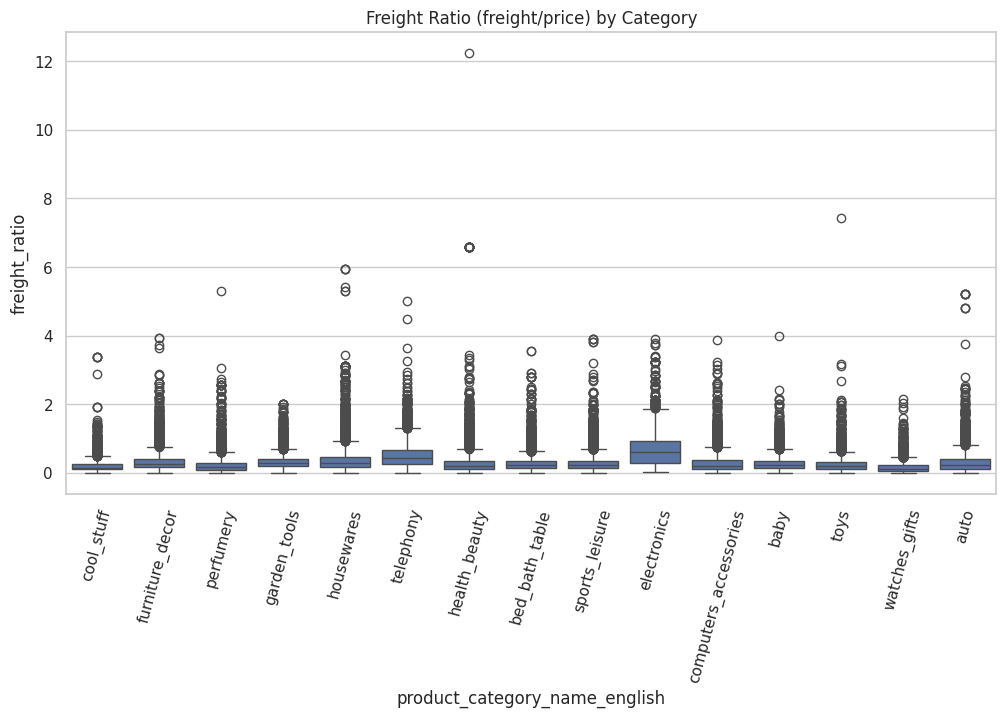

In [ ]:
#Q5: Freight as % of price vs weight/category
products = data["products"]
cat_trans = data["category_translation"]

items_full = (order_items.merge(products, on="product_id")
                         .merge(cat_trans, on="product_category_name", how="left"))
items_full["freight_ratio"] = items_full["freight_value"] / items_full["price"]

top_cats = items_full["product_category_name_english"].value_counts().head(15).index
subset = items_full[items_full["product_category_name_english"].isin(top_cats)]

plt.figure(figsize=(12,6))
sns.boxplot(data=subset, x="product_category_name_english", y="freight_ratio")
plt.xticks(rotation=75)
plt.title("Freight Ratio (freight/price) by Category")
plt.show()

late
False    4.152481
True     2.256572
Name: review_score, dtype: float64


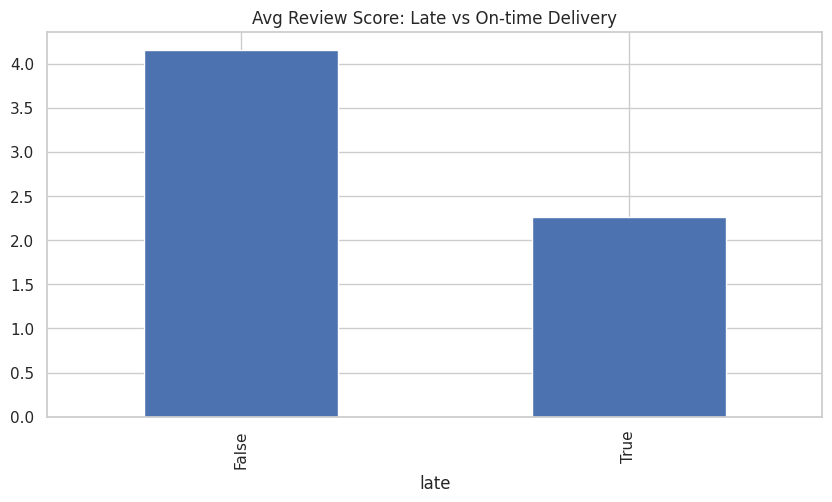

In [ ]:
#Q6: Review score attribution (delivery timing vs category)
model_df = (order_items.merge(products[["product_id","product_category_name"]], on="product_id")
                       .merge(orders, on="order_id")
                       .merge(reviews[["order_id","review_score"]], on="order_id"))

model_df["delay_vs_estimate_d"] = (model_df["order_delivered_customer_date"] - model_df["order_estimated_delivery_date"]).dt.days
model_df["late"] = model_df["delay_vs_estimate_d"] > 0

late_effect = model_df.groupby("late")["review_score"].mean()
print(late_effect)

late_effect.plot(kind="bar", title="Avg Review Score: Late vs On-time Delivery")
plt.show()

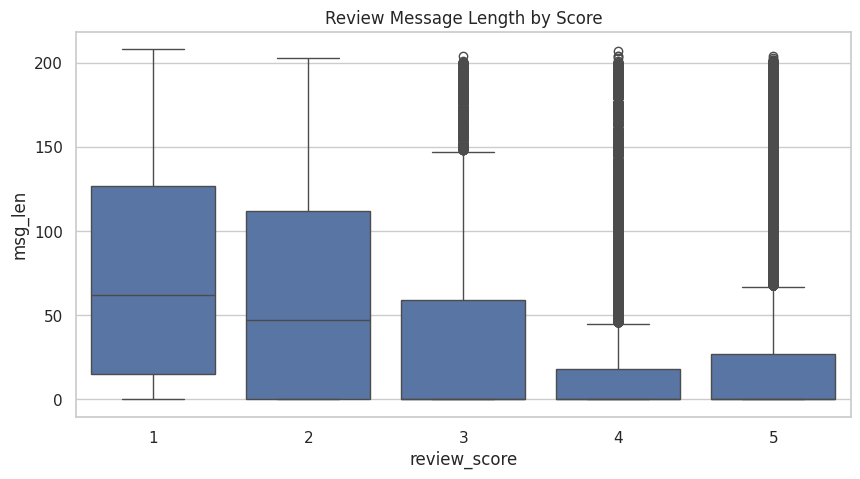

In [ ]:
#Q7: Review text length vs score
rev = reviews.copy()
rev["title_len"] = rev["review_comment_title"].fillna("").str.len()
rev["msg_len"] = rev["review_comment_message"].fillna("").str.len()

sns.boxplot(data=rev, x="review_score", y="msg_len")
plt.title("Review Message Length by Score")
plt.show()

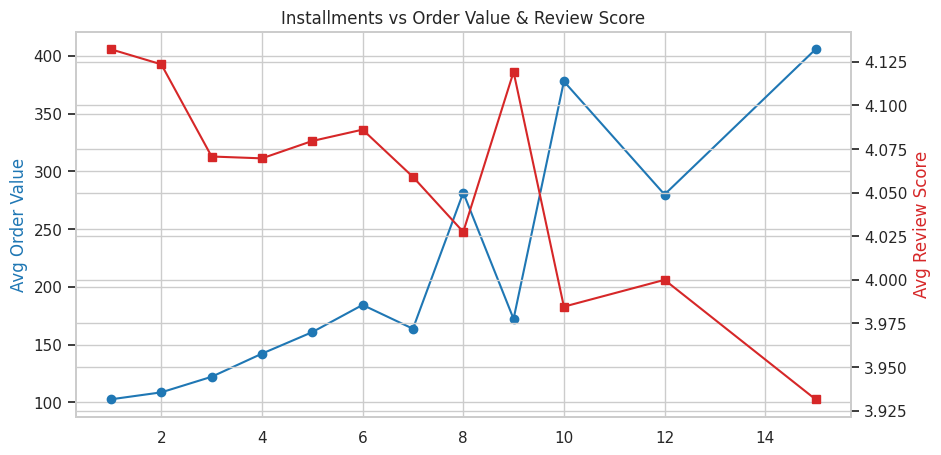

In [ ]:
#Q8: Installments vs cart value & satisfaction
payments = data["payments"]
order_value = order_items.groupby("order_id")["price"].sum().reset_index()

pay_full = (payments.merge(order_value, on="order_id")
                    .merge(reviews[["order_id","review_score"]], on="order_id", how="left"))

inst_group = pay_full.groupby("payment_installments").agg(
    avg_order_value=("price","mean"),
    avg_review=("review_score","mean"),
    n=("order_id","count")
).query("n > 30")

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(inst_group.index, inst_group["avg_order_value"], color="tab:blue", marker="o")
ax1.set_ylabel("Avg Order Value", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(inst_group.index, inst_group["avg_review"], color="tab:red", marker="s")
ax2.set_ylabel("Avg Review Score", color="tab:red")
plt.title("Installments vs Order Value & Review Score")
plt.show()

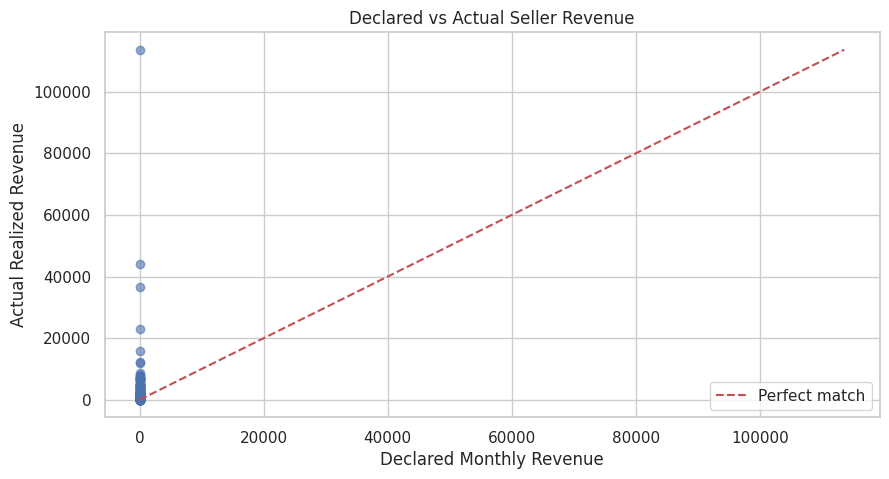

In [ ]:
#Q9: Declared vs realized performance mismatch
declared = closed[["seller_id","declared_product_catalog_size","declared_monthly_revenue"]]
mismatch = declared.merge(seller_perf, on="seller_id", how="inner").dropna(subset=["declared_monthly_revenue","revenue"])
mismatch["revenue_gap"] = mismatch["revenue"] - mismatch["declared_monthly_revenue"]
plt.figure(figsize=(10,5))
plt.scatter(mismatch["declared_monthly_revenue"], mismatch["revenue"], alpha=0.6)
max_val = max(mismatch["declared_monthly_revenue"].max(), mismatch["revenue"].max())
plt.plot([0, max_val], [0, max_val], 'r--', label="Perfect match")
plt.xlabel("Declared Monthly Revenue"); plt.ylabel("Actual Realized Revenue")
plt.legend(); plt.title("Declared vs Actual Seller Revenue")
plt.show()



---
# Purpose-1: Delivery Delay Impact on Review Scores


In [ ]:
# Unpack all datasets as standalone variables
orders        = data["orders"]
reviews       = data["reviews"]
customers     = data["customers"]
sellers       = data["sellers"]
order_items   = data["order_items"]
products      = data["products"]
payments      = data["payments"]
geolocation   = data["geolocation"]
cat_trans     = data["category_translation"]
mql           = data["mql"]
closed        = data["closed_deals"]

for name, df in [("orders",orders), ("reviews",reviews), ("customers",customers),
                  ("sellers",sellers), ("order_items",order_items), ("products",products),
                  ("payments",payments), ("geolocation",geolocation),
                  ("cat_trans",cat_trans), ("mql",mql), ("closed",closed)]:
    print(f"{name:12s} -> {df.shape}")

orders       -> (99441, 8)
reviews      -> (99224, 7)
customers    -> (99441, 5)
sellers      -> (3095, 4)
order_items  -> (112650, 7)
products     -> (32951, 9)
payments     -> (103886, 5)
geolocation  -> (1000163, 5)
cat_trans    -> (71, 2)
mql          -> (8000, 4)
closed       -> (842, 14)


In [ ]:
# Build one table with delivery metrics + review score
base = (orders.merge(reviews[["order_id","review_score"]], on="order_id", how="inner")
              .merge(customers[["customer_id","customer_state"]], on="customer_id", how="left"))

# Keep only delivered orders with valid timestamps
base = base.dropna(subset=["order_delivered_customer_date","order_estimated_delivery_date",
                            "order_purchase_timestamp"]).copy()

# Core metrics
base["delivery_days"] = (base["order_delivered_customer_date"] - base["order_purchase_timestamp"]).dt.days
base["delay_days"] = (base["order_delivered_customer_date"] - base["order_estimated_delivery_date"]).dt.days
base["is_late"] = base["delay_days"] > 0
base["low_review"] = base["review_score"] <= 2

print("Total delivered+reviewed orders:", len(base))
print("Late orders:", base["is_late"].sum(), f"({base['is_late'].mean()*100:.1f}%)")
print("\nDelivery days stats:\n", base["delivery_days"].describe())
print("\nDelay days stats:\n", base["delay_days"].describe())

Total delivered+reviewed orders: 96359
Late orders: 6410 (6.7%)

Delivery days stats:
 count    96359.000000
mean        12.058957
std          9.463076
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64

Delay days stats:
 count    96359.000000
mean       -11.917797
std         10.114024
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64


  delivery_bin  avg_review  n_orders  low_review_rate
0         0-3d    4.460329      8583         0.070838
1         4-7d    4.390490     25089         0.077524
2        8-14d    4.288356     36396         0.092702
3       15-21d    4.102334     15381         0.125024
4       22-30d    3.493955      6865         0.272105
5         30d+    2.175347      4032         0.652530


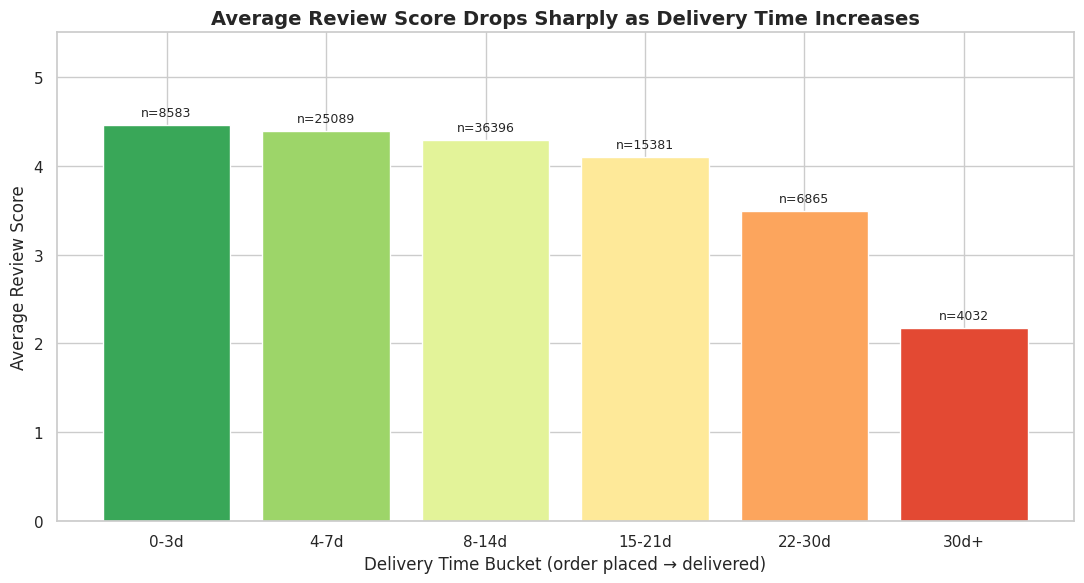

In [ ]:
# Bin delivery_days into meaningful buckets
bins = [0, 3, 7, 14, 21, 30, np.inf]
labels = ["0-3d", "4-7d", "8-14d", "15-21d", "22-30d", "30d+"]
base["delivery_bin"] = pd.cut(base["delivery_days"], bins=bins, labels=labels)

bin_summary = base.groupby("delivery_bin").agg(
    avg_review=("review_score","mean"),
    n_orders=("order_id","count"),
    low_review_rate=("low_review","mean")
).reset_index()
print(bin_summary)

fig, ax1 = plt.subplots(figsize=(11,6))
bars = ax1.bar(bin_summary["delivery_bin"].astype(str), bin_summary["avg_review"],
                color=sns.color_palette("RdYlGn", n_colors=len(bin_summary))[::-1])
ax1.set_ylabel("Average Review Score", fontsize=12)
ax1.set_xlabel("Delivery Time Bucket (order placed → delivered)", fontsize=12)
ax1.set_ylim(0, 5.5)
for bar, n in zip(bars, bin_summary["n_orders"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"n={n}", ha="center", fontsize=9)
plt.title("Average Review Score Drops Sharply as Delivery Time Increases", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

               avg_review  low_review_rate  n_orders
is_late                                             
On-time/Early    4.289842         0.092830     89949
Late             2.271139         0.624025      6410


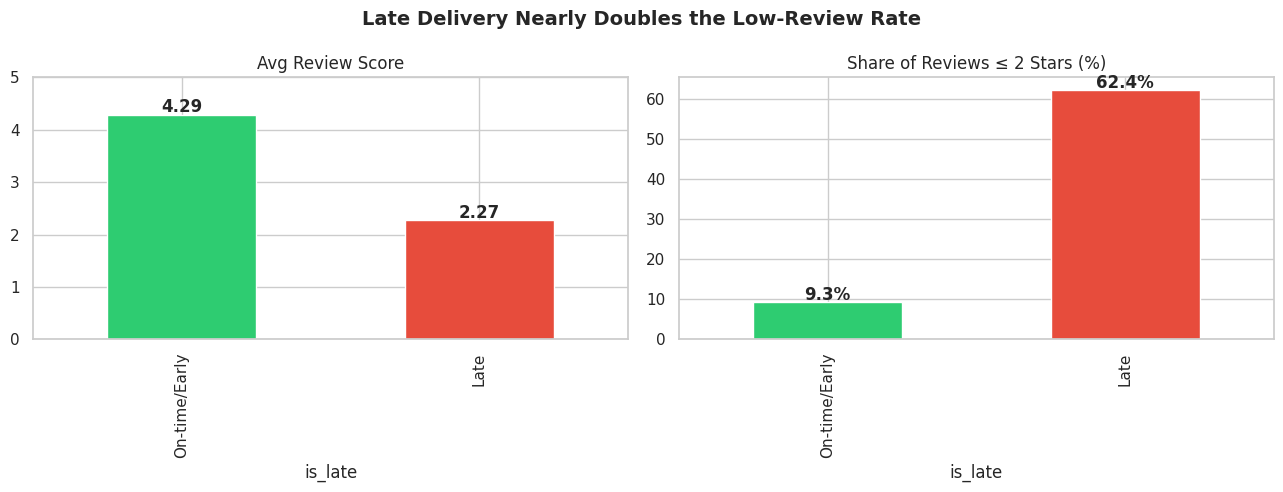


t-test: t=-100.97, p-value=0.00e+00  (significant if p < 0.05)


In [ ]:
late_compare = base.groupby("is_late").agg(
    avg_review=("review_score","mean"),
    low_review_rate=("low_review","mean"),
    n_orders=("order_id","count")
).rename(index={True:"Late", False:"On-time/Early"})
print(late_compare)

fig, ax = plt.subplots(1,2, figsize=(13,5))
late_compare["avg_review"].plot(kind="bar", ax=ax[0], color=["#2ecc71","#e74c3c"])
ax[0].set_title("Avg Review Score")
ax[0].set_ylim(0,5)
for i,v in enumerate(late_compare["avg_review"]):
    ax[0].text(i, v+0.05, f"{v:.2f}", ha="center", fontweight="bold")

(late_compare["low_review_rate"]*100).plot(kind="bar", ax=ax[1], color=["#2ecc71","#e74c3c"])
ax[1].set_title("Share of Reviews ≤ 2 Stars (%)")
for i,v in enumerate(late_compare["low_review_rate"]*100):
    ax[1].text(i, v+0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Late Delivery Nearly Doubles the Low-Review Rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Statistical significance check
from scipy import stats
late_scores = base[base["is_late"]]["review_score"]
ontime_scores = base[~base["is_late"]]["review_score"]
t_stat, p_val = stats.ttest_ind(late_scores, ontime_scores, equal_var=False)
print(f"\nt-test: t={t_stat:.2f}, p-value={p_val:.2e}  (significant if p < 0.05)")

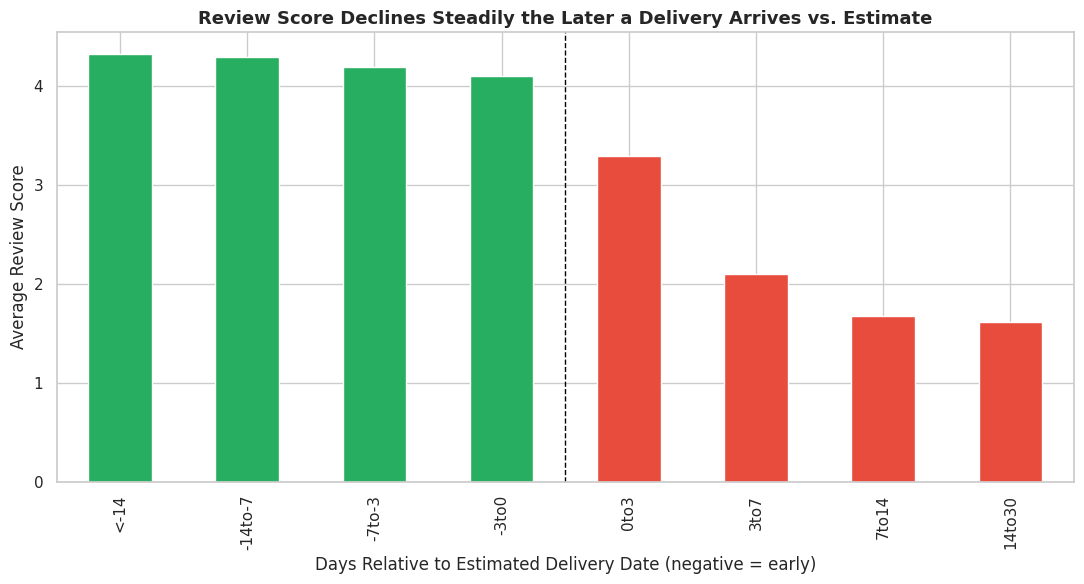

In [ ]:
# Cap extreme outliers for visualization only
plot_df = base[base["delay_days"].between(-30, 30)]

delay_bins = [-30,-14,-7,-3,0,3,7,14,30]
delay_labels = ["<-14","-14to-7","-7to-3","-3to0","0to3","3to7","7to14","14to30"]
plot_df["delay_bucket"] = pd.cut(plot_df["delay_days"], bins=delay_bins, labels=delay_labels)

delay_summary = plot_df.groupby("delay_bucket")["review_score"].mean()

plt.figure(figsize=(11,6))
colors = ["#27ae60" if "to0" in str(x) or x in ["<-14","-14to-7","-7to-3"] else "#e74c3c" for x in delay_summary.index]
delay_summary.plot(kind="bar", color=colors)
plt.axvline(x=3.5, color="black", linestyle="--", linewidth=1)  # boundary at delay=0
plt.ylabel("Average Review Score")
plt.xlabel("Days Relative to Estimated Delivery Date (negative = early)")
plt.title("Review Score Declines Steadily the Later a Delivery Arrives vs. Estimate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

                 avg_delivery_days  avg_review  late_rate  n_orders
same_state                                                         
Different State          14.635643    4.095000   0.078953     61695
Same State                7.472969    4.263328   0.044398     34664


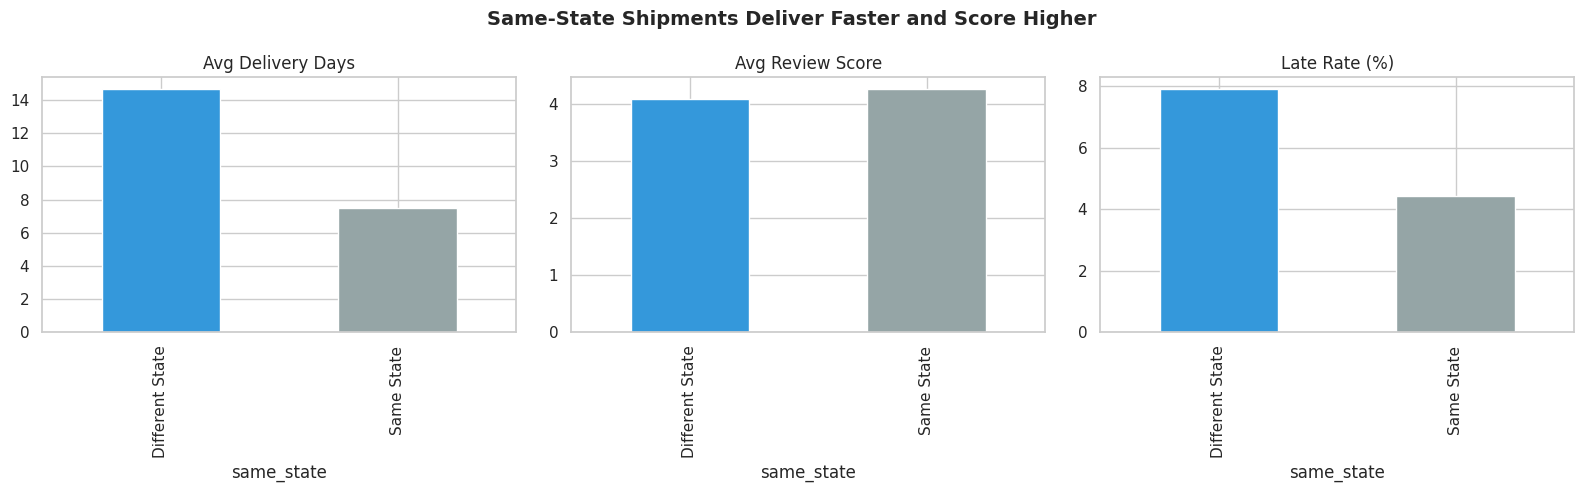

In [ ]:
route_state = (base.merge(order_items[["order_id","seller_id"]].drop_duplicates("order_id"), on="order_id", how="left")
                    .merge(sellers[["seller_id","seller_state"]], on="seller_id", how="left"))

route_state["same_state"] = route_state["seller_state"] == route_state["customer_state"]
route_state = route_state.dropna(subset=["seller_state","customer_state"])

same_state_summary = route_state.groupby("same_state").agg(
    avg_delivery_days=("delivery_days","mean"),
    avg_review=("review_score","mean"),
    late_rate=("is_late","mean"),
    n_orders=("order_id","count")
).rename(index={True:"Same State", False:"Different State"})
print(same_state_summary)

fig, ax = plt.subplots(1,3, figsize=(16,5))
same_state_summary["avg_delivery_days"].plot(kind="bar", ax=ax[0], color=["#3498db","#95a5a6"], title="Avg Delivery Days")
same_state_summary["avg_review"].plot(kind="bar", ax=ax[1], color=["#3498db","#95a5a6"], title="Avg Review Score")
(same_state_summary["late_rate"]*100).plot(kind="bar", ax=ax[2], color=["#3498db","#95a5a6"], title="Late Rate (%)")
plt.suptitle("Same-State Shipments Deliver Faster and Score Higher", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Find the delivery_days threshold where avg review crosses below 4.0
threshold_scan = base.groupby(base["delivery_days"])["review_score"].mean().reset_index()
threshold_scan = threshold_scan[threshold_scan["delivery_days"] <= 40]

crossing = threshold_scan[threshold_scan["review_score"] < 4.0]
critical_day = crossing["delivery_days"].min() if not crossing.empty else None

print(f"Average review score drops below 4.0 stars once delivery exceeds "
      f"{critical_day} days from purchase.")
print(f"Late deliveries show a low-review rate of {late_compare.loc['Late','low_review_rate']*100:.1f}% "
      f"vs {late_compare.loc['On-time/Early','low_review_rate']*100:.1f}% for on-time — "
      f"a {late_compare.loc['Late','low_review_rate']/late_compare.loc['On-time/Early','low_review_rate']:.1f}x increase.")
print(f"Same-state shipments deliver in {same_state_summary.loc['Same State','avg_delivery_days']:.1f} days on avg "
      f"vs {same_state_summary.loc['Different State','avg_delivery_days']:.1f} days cross-state.")

		📌 KEY FINDINGS:
    - Average review score drops below 4.0 stars once delivery exceeds 21 days from purchase.
		- Late deliveries show a low-review rate of 62.4% vs 9.3% for on-time — a 6.7x increase.
		- Same-state shipments deliver in 7.5 days on avg vs 14.6 days cross-state.



---
# Purpose 2: Regional Demand, Delivery Performance & Satisfaction


In [ ]:
state_base = (order_items.merge(orders, on="order_id")
                         .merge(customers[["customer_id","customer_state"]], on="customer_id")
                         .merge(reviews[["order_id","review_score"]], on="order_id", how="left"))

state_base = state_base.dropna(subset=["order_delivered_customer_date","order_estimated_delivery_date"])
state_base["delivery_days"] = (state_base["order_delivered_customer_date"] - state_base["order_purchase_timestamp"]).dt.days
state_base["delay_days"] = (state_base["order_delivered_customer_date"] - state_base["order_estimated_delivery_date"]).dt.days
state_base["is_late"] = state_base["delay_days"] > 0

                item_volume     revenue
customer_state                         
SP                    46709  5092419.12
RJ                    14227  1766628.36
MG                    12996  1558698.27
RS                     6181   732241.80
PR                     5673   668891.26
SC                     4113   508713.90
BA                     3703   495416.93
DF                     2381   298492.74
GO                     2297   285780.24
ES                     2236   269230.52


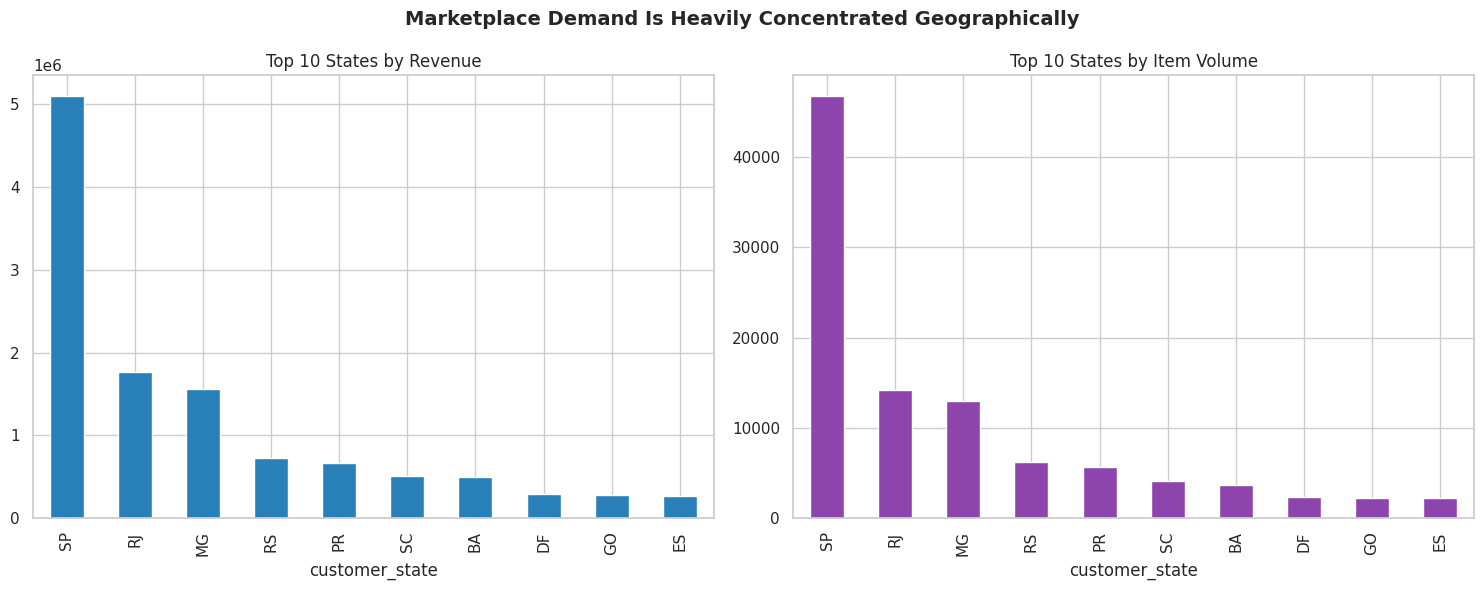


📌 Top 3 states account for 63.4% of total revenue.


In [ ]:
demand_by_state = state_base.groupby("customer_state").agg(
    item_volume=("order_item_id","count"),
    revenue=("price","sum")
).sort_values("revenue", ascending=False)

print(demand_by_state.head(10))

fig, ax = plt.subplots(1,2, figsize=(15,6))
demand_by_state["revenue"].head(10).plot(kind="bar", ax=ax[0], color="#2980b9", title="Top 10 States by Revenue")
demand_by_state["item_volume"].head(10).plot(kind="bar", ax=ax[1], color="#8e44ad", title="Top 10 States by Item Volume")
plt.suptitle("Marketplace Demand Is Heavily Concentrated Geographically", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

top3_share = demand_by_state["revenue"].head(3).sum() / demand_by_state["revenue"].sum() * 100
print(f"\n📌 Top 3 states account for {top3_share:.1f}% of total revenue.")

States excluded for low sample size (<30 orders):
[]

Top 10 highest-risk states (by late rate, reliable sample only):
   customer_state  n_orders  late_rate  avg_delivery_days  avg_review
1              AL       397   0.208817          23.983759    3.815421
9              MA       717   0.178882          21.139130    3.765957
24             SE       335   0.162667          20.978667    3.898123
5              CE      1279   0.136268          20.525507    3.867275
16             PI       476   0.135496          18.927481    3.961464
4              BA      3256   0.119363          18.788280    3.860725
18             RJ     12353   0.116188          14.698250    3.870998
13             PA       946   0.112158          23.313855    3.842459
21             RR        41   0.108696          27.826087    3.891304
14             PB       517   0.107325          20.098807    4.039587


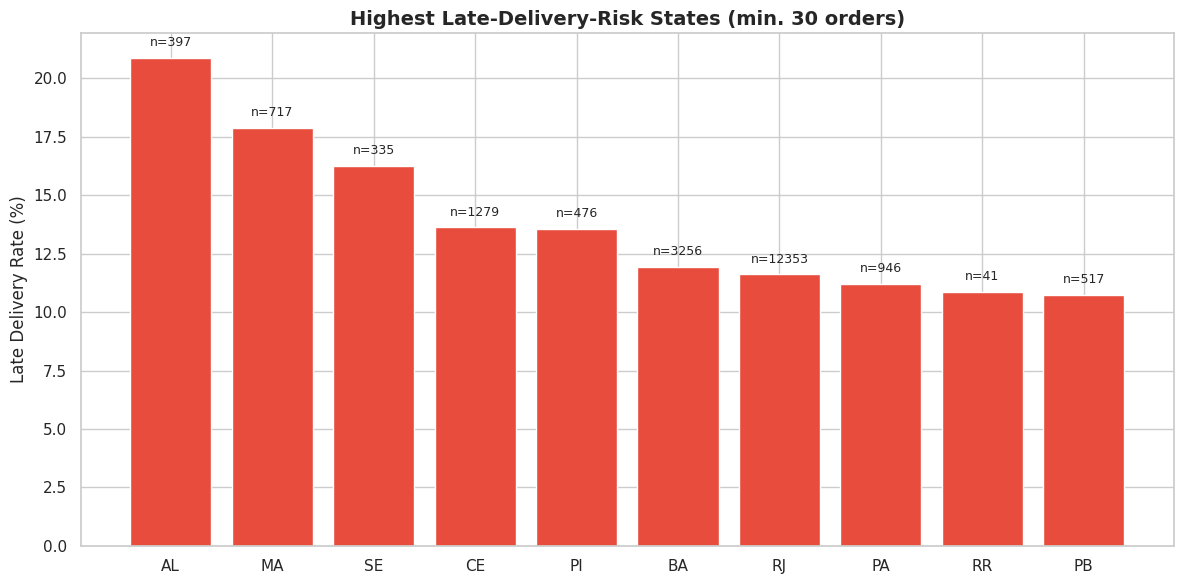

In [ ]:
risk_by_state = state_base.groupby("customer_state").agg(
    n_orders=("order_id","nunique"),
    avg_delivery_days=("delivery_days","mean"),
    late_rate=("is_late","mean"),
    avg_review=("review_score","mean")
).reset_index()

# only trust states with meaningful sample size
MIN_ORDERS = 30
risk_by_state["reliable"] = risk_by_state["n_orders"] >= MIN_ORDERS

reliable_risk = risk_by_state[risk_by_state["reliable"]].sort_values("late_rate", ascending=False)
print(f"States excluded for low sample size (<{MIN_ORDERS} orders):")
print(risk_by_state[~risk_by_state["reliable"]]["customer_state"].tolist())

print("\nTop 10 highest-risk states (by late rate, reliable sample only):")
print(reliable_risk[["customer_state","n_orders","late_rate","avg_delivery_days","avg_review"]].head(10))

plt.figure(figsize=(12,6))
top_risk = reliable_risk.head(10)
bars = plt.bar(top_risk["customer_state"], top_risk["late_rate"]*100, color="#e74c3c")
plt.ylabel("Late Delivery Rate (%)")
plt.title(f"Highest Late-Delivery-Risk States (min. {MIN_ORDERS} orders)", fontsize=14, fontweight="bold")
for bar, n in zip(bars, top_risk["n_orders"]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"n={n}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

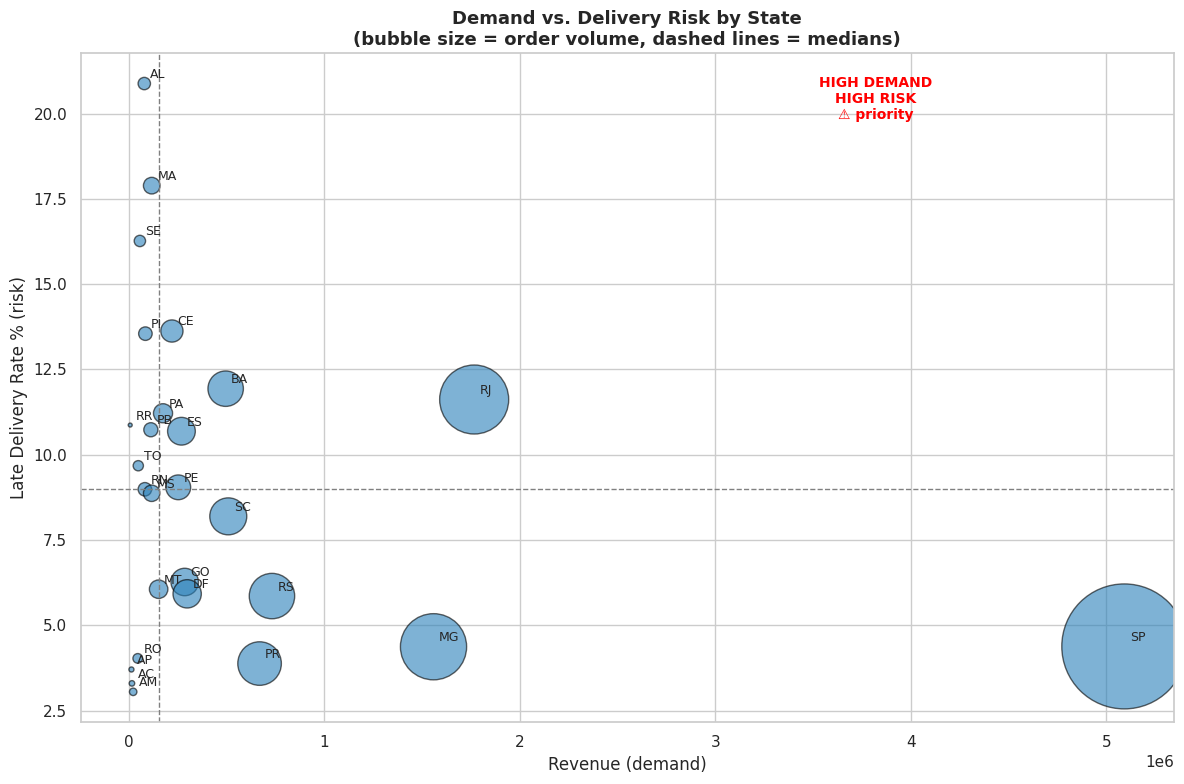

📌 HIGH-DEMAND + HIGH-RISK states (priority for intervention):
   customer_state     revenue  late_rate  n_orders
6              RJ  1766628.36   0.116188     12353
5              BA   495416.93   0.119363      3256
10             ES   269230.52   0.106887      1995
12             PE   252903.10   0.090444      1593
3              CE   220434.27   0.136268      1279
7              PA   174952.64   0.112158       946


In [ ]:
quadrant = reliable_risk.merge(demand_by_state.reset_index(), on="customer_state")
quadrant["revenue_rank"] = quadrant["revenue"].rank(ascending=False)
quadrant["risk_rank"] = quadrant["late_rate"].rank(ascending=False)

median_rev = quadrant["revenue"].median()
median_late = quadrant["late_rate"].median()

plt.figure(figsize=(12,8))
plt.scatter(quadrant["revenue"], quadrant["late_rate"]*100,
            s=quadrant["n_orders"]/5, alpha=0.6, color="#2980b9", edgecolor="black")

for _, row in quadrant.iterrows():
    plt.annotate(row["customer_state"], (row["revenue"], row["late_rate"]*100),
                 fontsize=9, xytext=(4,4), textcoords="offset points")

plt.axvline(median_rev, color="gray", linestyle="--", linewidth=1)
plt.axhline(median_late*100, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Revenue (demand)")
plt.ylabel("Late Delivery Rate % (risk)")
plt.title("Demand vs. Delivery Risk by State\n(bubble size = order volume, dashed lines = medians)",
          fontsize=13, fontweight="bold")
plt.text(quadrant["revenue"].max()*0.75, quadrant["late_rate"].max()*100*0.95,
          "HIGH DEMAND\nHIGH RISK\n priority", color="red", fontsize=10, ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# Flag the priority quadrant explicitly
priority_states = quadrant[(quadrant["revenue"] > median_rev) & (quadrant["late_rate"] > median_late)]
print("📌 HIGH-DEMAND + HIGH-RISK states (priority for intervention):")
print(priority_states[["customer_state","revenue","late_rate","n_orders"]].sort_values("revenue", ascending=False))

Worst-performing seller→customer state routes (min. 20 orders):
    seller_state customer_state  n_orders  late_rate
254           PR             AL        43   0.325581
57            DF             ES        22   0.318182
285           RJ             CE        56   0.232143
386           SP             AL       273   0.227106
142           MA             SP       130   0.215385
394           SP             MA       549   0.196721
71            DF             SC        26   0.192308
158           MG             PB        58   0.189655
277           PR             SE        22   0.181818
361           SC             MA        22   0.181818


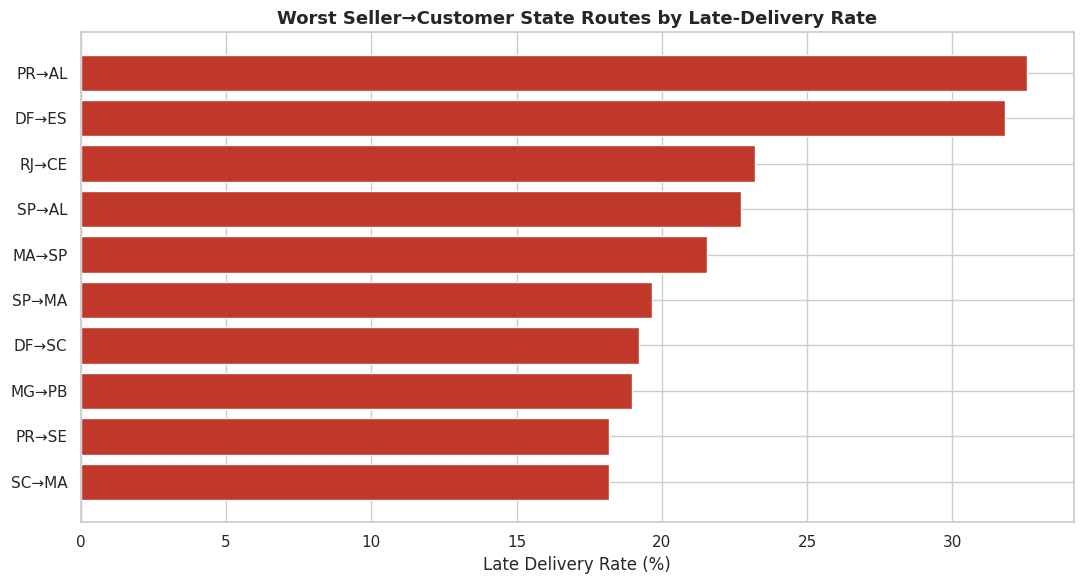

In [ ]:
route_full = (order_items.merge(sellers[["seller_id","seller_state"]], on="seller_id")
                         .merge(orders, on="order_id")
                         .merge(customers[["customer_id","customer_state"]], on="customer_id"))
route_full = route_full.dropna(subset=["order_delivered_customer_date","order_estimated_delivery_date"])
route_full["delay_days"] = (route_full["order_delivered_customer_date"] - route_full["order_estimated_delivery_date"]).dt.days
route_full["is_late"] = route_full["delay_days"] > 0

# Only look at seller_state -> customer_state pairs with enough volume to be meaningful
route_summary = route_full.groupby(["seller_state","customer_state"]).agg(
    n_orders=("order_id","count"),
    late_rate=("is_late","mean")
).reset_index()
route_summary = route_summary[route_summary["n_orders"] >= 20]   # sample-size guardrail

worst_routes = route_summary.sort_values("late_rate", ascending=False).head(10)
print("Worst-performing seller→customer state routes (min. 20 orders):")
print(worst_routes)

plt.figure(figsize=(11,6))
route_labels = worst_routes["seller_state"] + "→" + worst_routes["customer_state"]
plt.barh(route_labels, worst_routes["late_rate"]*100, color="#c0392b")
plt.xlabel("Late Delivery Rate (%)")
plt.title("Worst Seller→Customer State Routes by Late-Delivery Rate", fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
print(f"""
1. DEMAND CONCENTRATION: Top 3 states drive {top3_share:.1f}% of revenue —
   ({', '.join(demand_by_state.head(3).index)})

2. RISK CONCENTRATION: Highest late-delivery-rate states (reliable sample, n≥{MIN_ORDERS}):
   {', '.join(reliable_risk.head(3)['customer_state'].tolist())}

3. PRIORITY ZONE (high demand AND high risk — biggest ROI for fixing):
   {', '.join(priority_states['customer_state'].tolist()) if len(priority_states) > 0 else 'None crossed both medians — demand and risk are largely decoupled.'}

4. WORST ROUTES: {worst_routes.iloc[0]['seller_state']} → {worst_routes.iloc[0]['customer_state']}
   shows a {worst_routes.iloc[0]['late_rate']*100:.1f}% late rate on {worst_routes.iloc[0]['n_orders']} orders.
""")

1. DEMAND CONCENTRATION: Top 3 states drive 63.4% of revenue —
   (SP, RJ, MG)

2. RISK CONCENTRATION: Highest late-delivery-rate states (reliable sample, n≥30):
   AL, MA, SE

3. PRIORITY ZONE (high demand AND high risk — biggest ROI for fixing):
   CE, BA, RJ, PA, ES, PE

4. WORST ROUTES: PR → AL
   shows a 32.6% late rate on 43 orders.